In [32]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/ny/od/ny_od_main_JT00_2023.csv.gz
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/ny/od/ny_od_aux_JT00_2023.csv.gz
Total OD rows loaded: 8529759
Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/ny/ny_xwalk.csv.gz
Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/ny/ny_xwalk.csv.gz
Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/nj/nj_xwalk.csv.gz
Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/ct/ct_xwalk.csv.gz
Home crosswalk blocks: 476717
Rows with workplace in NYC counties: 4112109
Rows after adding home county (NY/NJ/CT): 4008455
Unique home counties: 92
Unique NYC work counties: 5
Kept origin counties (covering 95% of flows): 17
Total counties kept (origins + NYC destinations): 17
OD pairs plotted: 85
Counties in basemap: 17
Flow lines created: 85


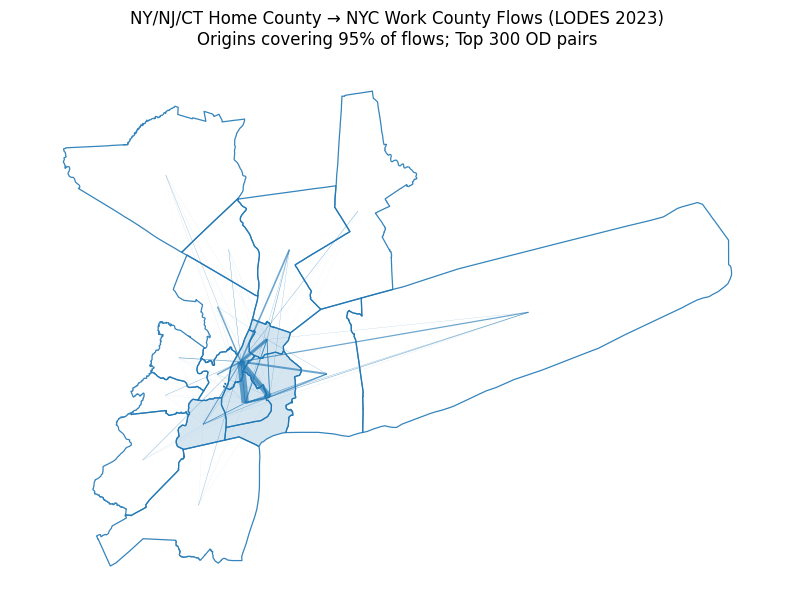

,county_geoid,NAME,STATEFP
0,09190,Western Connecticut,09
1,34003,Bergen,34
2,34013,Essex,34
3,34017,Hudson,34
4,34023,Middlesex,34
5,34025,Monmouth,34
6,34039,Union,34
7,36005,Bronx,36
8,36047,Kings,36
9,36059,Nassau,36


In [52]:
# ============================================================
# NYC Workplace-Focused County-to-County OD Flow Map (LODES)
# Includes origins in NY + NJ + CT (optional PA add shown)
# Produces a filtered "top-share" map (e.g., origins covering 95% of flows)
# ============================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# -----------------------------
# 0) SETTINGS
# -----------------------------
YEAR = 2023          # try 2023; if 404, change to 2022
JOBTYPE = "JT00"     # all jobs
TOP_N = 300          # max county-to-county pairs to draw
CUM_SHARE_KEEP = 0.95  # keep origin counties covering this share of flows into NYC

# NYC county FIPS (5-digit GEOID = state+county)
NYC_COUNTIES = {"36005", "36047", "36061", "36081", "36085"}  # Bronx, Kings, New York, Queens, Richmond

# Origin states to include for HOME counties
ORIGIN_STATES = ["ny", "nj", "ct"]   # add "pa" if you want (see note below)

# -----------------------------
# 1) HELPERS
# -----------------------------
def read_lodes_od(state: str, year: int, jobtype: str = "JT00", main: bool = True) -> pd.DataFrame:
    """
    Read LODES OD file from the Census directory.
    main=True  -> state_od_main_...
    main=False -> state_od_aux_...
    """
    part = "main" if main else "aux"
    url = f"https://lehd.ces.census.gov/data/lodes/LODES8/{state}/od/{state}_od_{part}_{jobtype}_{year}.csv.gz"
    print("Reading OD:", url)
    df = pd.read_csv(url, dtype={"h_geocode": "string", "w_geocode": "string"})
    return df[["h_geocode", "w_geocode", "S000"]]

def read_xwalk(state: str) -> pd.DataFrame:
    """
    Read LODES crosswalk for a state (block -> county).
    """
    url = f"https://lehd.ces.census.gov/data/lodes/LODES8/{state}/{state}_xwalk.csv.gz"
    print("Reading XWALK:", url)
    return pd.read_csv(url, dtype="string", usecols=["tabblk2020", "cty", "ctyname"])

# Map state abbreviations to STATEFP for TIGER counties
STATEFP = {"ny": "36", "nj": "34", "ct": "09", "pa": "42"}

# -----------------------------
# 2) READ OD (NY main + NY aux) AND COMBINE
# -----------------------------
od_main = read_lodes_od("ny", YEAR, JOBTYPE, main=True)
od_aux  = read_lodes_od("ny", YEAR, JOBTYPE, main=False)
od = pd.concat([od_main, od_aux], ignore_index=True)
print("Total OD rows loaded:", len(od))

# -----------------------------
# 3) READ CROSSWALKS
#    - Workplaces are NYC -> need NY crosswalk for work-side
#    - Homes can be NY/NJ/CT -> combine those for home-side
# -----------------------------
xwalk_ny = read_xwalk("ny")

xwalk_list = [read_xwalk(s) for s in ORIGIN_STATES]
xwalk_home = pd.concat(xwalk_list, ignore_index=True).drop_duplicates("tabblk2020")
print("Home crosswalk blocks:", len(xwalk_home))

# If you also want PA commuters:
# ORIGIN_STATES = ["ny","nj","ct","pa"]  # set above and rerun the crosswalk section

# -----------------------------
# 4) FILTER OD TO NYC WORKPLACE BLOCKS (using NY crosswalk)
# -----------------------------
od_w = od.merge(
    xwalk_ny[["tabblk2020", "cty", "ctyname"]],
    left_on="w_geocode",
    right_on="tabblk2020",
    how="inner",
    validate="m:1"
).rename(columns={"cty": "work_county", "ctyname": "work_county_name"}).drop(columns=["tabblk2020"])

od_w_nyc = od_w[od_w["work_county"].isin(NYC_COUNTIES)].copy()
print("Rows with workplace in NYC counties:", len(od_w_nyc))

# -----------------------------
# 5) ATTACH HOME COUNTY (NY/NJ/CT) USING COMBINED HOME CROSSWALK
# -----------------------------
od_wh = od_w_nyc.merge(
    xwalk_home[["tabblk2020", "cty", "ctyname"]],
    left_on="h_geocode",
    right_on="tabblk2020",
    how="left",
    validate="m:1"
).rename(columns={"cty": "home_county", "ctyname": "home_county_name"}).drop(columns=["tabblk2020"])

# Drop anything still missing home county (e.g., if you didn't include a commuter origin state)
od_wh = od_wh.dropna(subset=["home_county"]).copy()
print("Rows after adding home county (NY/NJ/CT):", len(od_wh))

# -----------------------------
# 6) AGGREGATE TO COUNTY-TO-COUNTY OD MATRIX
# -----------------------------
od_county = (
    od_wh.groupby(
        ["home_county", "home_county_name", "work_county", "work_county_name"],
        as_index=False
    )["S000"].sum()
)
od_county = od_county[od_county["S000"] > 0].copy()

print("Unique home counties:", od_county["home_county"].nunique())
print("Unique NYC work counties:", od_county["work_county"].nunique())

# -----------------------------
# 7) FILTER ORIGIN COUNTIES BY CUMULATIVE FLOW SHARE (e.g., 95%)
# -----------------------------
home_totals = (
    od_county.groupby("home_county", as_index=False)["S000"]
    .sum()
    .sort_values("S000", ascending=False)
)

home_totals["cum_share"] = home_totals["S000"].cumsum() / home_totals["S000"].sum()
keep_home = set(home_totals.loc[home_totals["cum_share"] <= CUM_SHARE_KEEP, "home_county"])
keep = keep_home | NYC_COUNTIES

print(f"Kept origin counties (covering {int(CUM_SHARE_KEEP*100)}% of flows):", len(keep_home))
print("Total counties kept (origins + NYC destinations):", len(keep))

# Filter OD pairs to kept origin counties -> NYC destinations
od_county_filtered = od_county[
    od_county["home_county"].isin(keep_home) &
    od_county["work_county"].isin(NYC_COUNTIES)
].copy()

# For plotting lines, keep top N pairs
top = od_county_filtered.sort_values("S000", ascending=False).head(TOP_N).copy()
print("OD pairs plotted:", len(top))

# -----------------------------
# 8) DOWNLOAD COUNTY GEOMETRIES (NY + NJ + CT) AND FILTER TO KEPT COUNTIES
# -----------------------------
counties_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
counties = gpd.read_file(counties_url)

counties["county_geoid"] = counties["STATEFP"] + counties["COUNTYFP"]

# Keep only the states we included for home origins + NY (for NYC destinations)
statefps = sorted({STATEFP[s] for s in ORIGIN_STATES} | {STATEFP["ny"]})
counties_tri = counties[counties["STATEFP"].isin(statefps)].copy()

# Filter basemap to just kept counties
counties_part = counties_tri[counties_tri["county_geoid"].isin(keep)].copy()

# Project to Web Mercator for easy plotting
counties_part = counties_part.to_crs(3857)

print("Counties in basemap:", len(counties_part))

# -----------------------------
# 9) BUILD CENTROIDS + FLOW LINES
# -----------------------------
cent = counties_part.copy()
cent["geometry"] = cent.geometry.centroid
cent = cent[["county_geoid", "NAME", "geometry"]].copy()

# Merge centroids onto OD pairs
top = top.merge(
    cent.rename(columns={"county_geoid": "home_county", "geometry": "home_geom"}),
    on="home_county",
    how="left"
)
top = top.merge(
    cent.rename(columns={"county_geoid": "work_county", "geometry": "work_geom"}),
    on="work_county",
    how="left"
)

top = top.dropna(subset=["home_geom", "work_geom"]).copy()
top["geometry"] = top.apply(lambda r: LineString([r["home_geom"], r["work_geom"]]), axis=1)

flows = gpd.GeoDataFrame(top, geometry="geometry", crs=cent.crs)
print("Flow lines created:", len(flows))

# -----------------------------
# 10) PLOT (CROPPED)
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Basemap outlines
counties_part.boundary.plot(ax=ax, linewidth=0.9, alpha=0.9)

# Highlight NYC counties
counties_part[counties_part["county_geoid"].isin(NYC_COUNTIES)].plot(ax=ax, alpha=0.18)

# Flow line widths
lw = (flows["S000"] / flows["S000"].max()) * 6
flows.plot(ax=ax, linewidth=lw, alpha=0.65)

# Crop to kept counties bounds (pad a bit)
minx, miny, maxx, maxy = counties_part.total_bounds
padx = (maxx - minx) * 0.08
pady = (maxy - miny) * 0.08
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

ax.set_title(
    f"NY/NJ/CT Home County → NYC Work County Flows (LODES {YEAR})\n"
    f"Origins covering {int(CUM_SHARE_KEEP*100)}% of flows; Top {TOP_N} OD pairs"
)
ax.axis("off")
plt.show()

# -----------------------------
# 11) (OPTIONAL) LIST KEPT COUNTIES BY NAME
# -----------------------------
kept_list = counties_tri[counties_tri["county_geoid"].isin(keep)][["county_geoid", "NAME", "STATEFP"]].sort_values(["STATEFP","NAME"])
kept_list.reset_index(drop=True)

Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/ny/ny_xwalk.csv.gz
Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/nj/nj_xwalk.csv.gz
Reading XWALK: https://lehd.ces.census.gov/data/lodes/LODES8/ct/ct_xwalk.csv.gz
Combined crosswalk blocks: 476717
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/ny/od/ny_od_main_JT00_2023.csv.gz
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/ny/od/ny_od_aux_JT00_2023.csv.gz
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/nj/od/nj_od_main_JT00_2023.csv.gz
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/nj/od/nj_od_aux_JT00_2023.csv.gz
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/ct/od/ct_od_main_JT00_2023.csv.gz
Reading OD: https://lehd.ces.census.gov/data/lodes/LODES8/ct/od/ct_od_aux_JT00_2023.csv.gz
Total OD rows loaded (NY+NJ+CT workplaces): 13912638
Rows after keeping only NY/NJ/CT on both ends: 13455429
County-to-county NYC-connected pairs: 877
Participating counties (pr

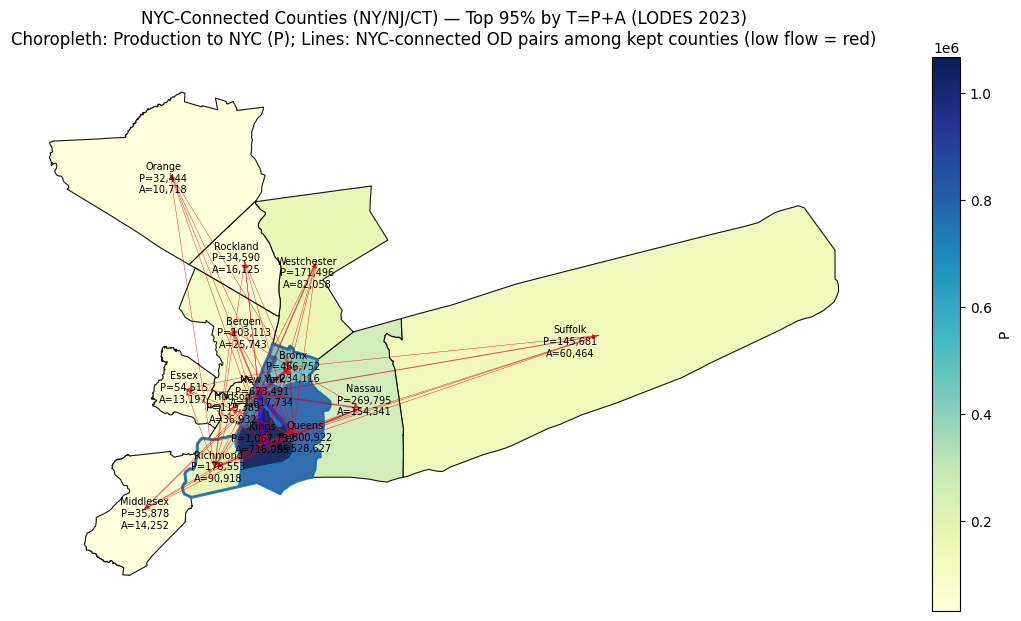

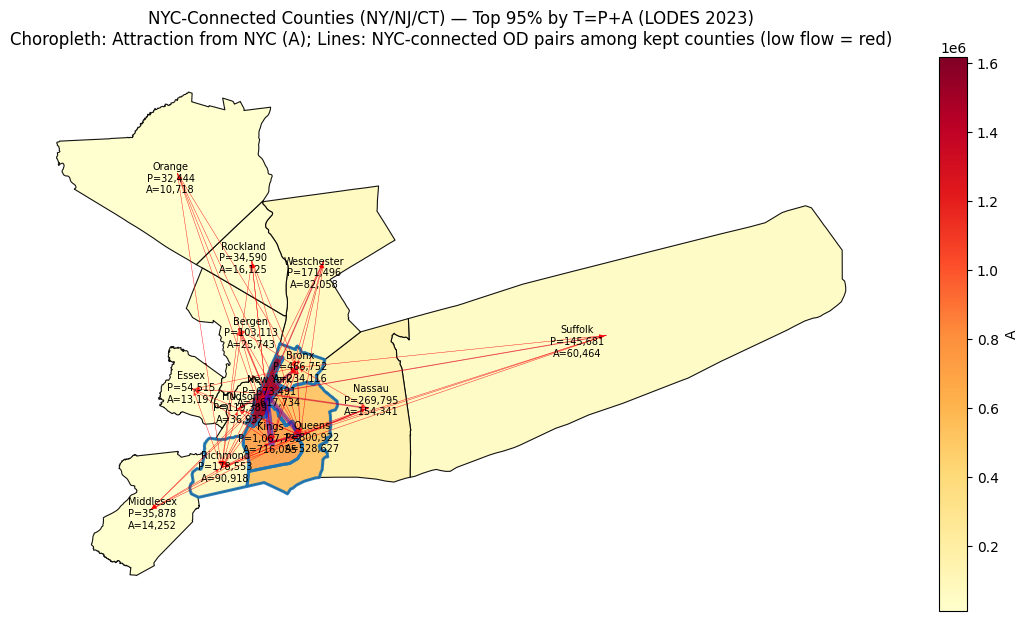

In [60]:
# ============================================================
# NYC-Connected County Flows (FULLY SYMMETRIC, NY+NJ+CT LODES OD)
# + 95% FILTER (by total connected trips T = P + A)
# + Flow lines between filtered counties
# + Low-flow lines colored RED
# + Directional arrowheads
#
# Definitions (NYC = 5 county-boroughs):
#   P(county) = total flow county -> NYC  (production to NYC)
#   A(county) = total flow NYC -> county  (attraction from NYC)
#   T(county) = P + A  (total NYC-connected volume for that county)
#
# Filtering:
#   Keep counties that cumulatively account for 95% of total T (plus always keep NYC)
#   Then draw ALL NYC-connected OD pairs among the kept counties.
#
# Notes:
# - Arrowheads on a huge number of lines can get slow/cluttered.
#   Use TOP_LINE_PAIRS / MAX_ARROWS if needed.
# ============================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from matplotlib.colors import Normalize, LinearSegmentedColormap
import numpy as np

# -----------------------------
# 0) SETTINGS
# -----------------------------
YEAR = 2023       # if 404, change to 2022
JOBTYPE = "JT00"

STATES = ["ny", "nj", "ct"]  # symmetric tri-state (workplace states + crosswalk states)

STATEFP = {"ny": "36", "nj": "34", "ct": "09"}
STATEABBR_FROM_FP = {"36": "NY", "34": "NJ", "09": "CT"}

NYC_COUNTIES = {"36005", "36047", "36061", "36081", "36085"}  # Bronx, Kings, NY, Queens, Richmond

CUM_SHARE_KEEP = 0.95

# Visualization controls
TOP_LINE_PAIRS = None   # e.g., 1200 to reduce clutter; None = draw all kept-pair lines
MAX_ARROWS = 800        # arrowheads are heavy; cap for readability. Set None for all (not recommended).
ARROW_SIZE = 7          # arrowhead size
ARROW_ALPHA = 0.70
LINE_ALPHA = 0.55

# Choropleth palettes
CMAP_P = "YlGnBu"  # P map
CMAP_A = "YlOrRd"  # A map

# Line color: low flows RED -> high flows BLUE (low must be red per your request)
LINE_CMAP = LinearSegmentedColormap.from_list("lowred_highblue", ["red", "blue"])

# -----------------------------
# 1) HELPERS
# -----------------------------
def read_lodes_od(state: str, year: int, jobtype: str = "JT00", main: bool = True) -> pd.DataFrame:
    part = "main" if main else "aux"
    url = f"https://lehd.ces.census.gov/data/lodes/LODES8/{state}/od/{state}_od_{part}_{jobtype}_{year}.csv.gz"
    print("Reading OD:", url)
    df = pd.read_csv(url, dtype={"h_geocode": "string", "w_geocode": "string"})
    df = df[["h_geocode", "w_geocode", "S000"]]
    df["work_state"] = state
    df["od_part"] = part
    return df

def read_xwalk(state: str) -> pd.DataFrame:
    url = f"https://lehd.ces.census.gov/data/lodes/LODES8/{state}/{state}_xwalk.csv.gz"
    print("Reading XWALK:", url)
    xw = pd.read_csv(url, dtype="string", usecols=["tabblk2020", "cty", "ctyname"])
    xw["state"] = state
    return xw

def add_state_cols(df: pd.DataFrame, geoid_col: str, out_statefp_col: str, out_state_col: str) -> pd.DataFrame:
    df[out_statefp_col] = df[geoid_col].astype(str).str[:2]
    df[out_state_col] = df[out_statefp_col].map(STATEABBR_FROM_FP)
    return df

def draw_arrows(ax, gdf_lines, color_list, max_arrows=800, size=7, alpha=0.7):
    """
    Draw arrowheads along lines. Uses a segment close to the end of each line.
    For readability and speed, consider limiting max_arrows.
    """
    if max_arrows is not None and len(gdf_lines) > max_arrows:
        # sample by largest flows so the most important arrows show
        gdf_use = gdf_lines.sort_values("S000", ascending=False).head(max_arrows).copy()
        colors_use = [color_list[i] for i in gdf_use.index.to_list()]
    else:
        gdf_use = gdf_lines
        colors_use = color_list

    for (idx, row), c in zip(gdf_use.iterrows(), colors_use):
        line = row.geometry
        if line is None or line.length == 0:
            continue

        # Use points at 85% and 100% along line for a short arrow segment
        p1 = line.interpolate(0.85, normalized=True)
        p2 = line.interpolate(1.00, normalized=True)

        ax.annotate(
            "",
            xy=(p2.x, p2.y),
            xytext=(p1.x, p1.y),
            arrowprops=dict(arrowstyle="-|>", color=c, lw=0, mutation_scale=size, alpha=alpha),
        )

# -----------------------------
# 2) LOAD CROSSWALKS (NY/NJ/CT)
# -----------------------------
xwalk_all = pd.concat([read_xwalk(s) for s in STATES], ignore_index=True).drop_duplicates("tabblk2020")
xwalk_all = xwalk_all.rename(columns={"tabblk2020": "block", "cty": "county_geoid", "ctyname": "county_name"})
print("Combined crosswalk blocks:", len(xwalk_all))

# -----------------------------
# 3) LOAD OD FOR WORKPLACE STATES (NY/NJ/CT), MAIN + AUX  (SYMMETRIC)
# -----------------------------
od_frames = []
for s in STATES:
    od_frames.append(read_lodes_od(s, YEAR, JOBTYPE, main=True))
    od_frames.append(read_lodes_od(s, YEAR, JOBTYPE, main=False))
od = pd.concat(od_frames, ignore_index=True)
print("Total OD rows loaded (NY+NJ+CT workplaces):", len(od))

# -----------------------------
# 4) MAP HOME + WORK BLOCKS TO COUNTIES (NY/NJ/CT only)
# -----------------------------
# Home county
od2 = od.merge(
    xwalk_all[["block", "county_geoid", "county_name"]],
    left_on="h_geocode",
    right_on="block",
    how="left",
    validate="m:1",
).rename(columns={"county_geoid": "home_county", "county_name": "home_county_name"}).drop(columns=["block"])

# Work county
od2 = od2.merge(
    xwalk_all[["block", "county_geoid", "county_name"]],
    left_on="w_geocode",
    right_on="block",
    how="left",
    validate="m:1",
).rename(columns={"county_geoid": "work_county", "county_name": "work_county_name"}).drop(columns=["block"])

# Keep only NY/NJ/CT on both ends
od2 = od2.dropna(subset=["home_county", "work_county"]).copy()
od2["home_county"] = od2["home_county"].astype(str)
od2["work_county"] = od2["work_county"].astype(str)
print("Rows after keeping only NY/NJ/CT on both ends:", len(od2))

# -----------------------------
# 5) NYC-CONNECTED FLOWS (NYC in origin OR destination)
# -----------------------------
nyc_connected = od2[
    od2["home_county"].isin(NYC_COUNTIES) | od2["work_county"].isin(NYC_COUNTIES)
].copy()

# County-to-county OD pairs (NYC-connected)
flows_cc = (
    nyc_connected.groupby(
        ["home_county","home_county_name","work_county","work_county_name"],
        as_index=False
    )["S000"].sum()
)
flows_cc = flows_cc[flows_cc["S000"] > 0].copy()
print("County-to-county NYC-connected pairs:", len(flows_cc))

# -----------------------------
# 6) COMPUTE P, A for ALL counties appearing in NYC-connected flows
# P(county) = county -> NYC
# A(county) = NYC -> county
# -----------------------------
P = (
    flows_cc[flows_cc["work_county"].isin(NYC_COUNTIES)]
    .groupby(["home_county","home_county_name"], as_index=False)["S000"].sum()
    .rename(columns={"home_county":"county_geoid","home_county_name":"county_name","S000":"P"})
)

A = (
    flows_cc[flows_cc["home_county"].isin(NYC_COUNTIES)]
    .groupby(["work_county","work_county_name"], as_index=False)["S000"].sum()
    .rename(columns={"work_county":"county_geoid","work_county_name":"county_name","S000":"A"})
)

# -----------------------------
# 7) LOAD COUNTY GEOMETRIES (NY/NJ/CT) and MERGE P, A
# -----------------------------
counties_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
counties = gpd.read_file(counties_url)
counties["county_geoid"] = counties["STATEFP"] + counties["COUNTYFP"]

keep_statefps = [STATEFP[s] for s in STATES]
counties_tri = counties[counties["STATEFP"].isin(keep_statefps)].copy()

# Participating counties = any county that appears in NYC-connected flows
participating = set(flows_cc["home_county"].unique()) | set(flows_cc["work_county"].unique())
participating = {c for c in participating if pd.notna(c)}
print("Participating counties (pre-95%):", len(participating))

map_gdf = counties_tri[counties_tri["county_geoid"].isin(participating)].copy().to_crs(3857)

map_gdf = map_gdf.merge(P[["county_geoid","P"]], on="county_geoid", how="left")
map_gdf = map_gdf.merge(A[["county_geoid","A"]], on="county_geoid", how="left")
map_gdf["P"] = map_gdf["P"].fillna(0).astype(int)
map_gdf["A"] = map_gdf["A"].fillna(0).astype(int)
map_gdf["T"] = map_gdf["P"] + map_gdf["A"]

# -----------------------------
# 8) 95% FILTER (by T = P + A) + ALWAYS KEEP NYC
# -----------------------------
sorted_g = map_gdf.sort_values("T", ascending=False).copy()
total_T = sorted_g["T"].sum()
sorted_g["cumshare"] = sorted_g["T"].cumsum() / (total_T if total_T > 0 else 1)

keep_95 = set(sorted_g.loc[sorted_g["cumshare"] <= CUM_SHARE_KEEP, "county_geoid"].astype(str).tolist())
keep_95 |= NYC_COUNTIES  # always keep NYC

map_95 = map_gdf[map_gdf["county_geoid"].isin(keep_95)].copy()
print("Counties after 95% filter:", len(map_95))

# -----------------------------
# 9) FILTER OD PAIRS TO KEPT COUNTIES + OPTIONAL TOP N LINE PAIRS
# -----------------------------
flows_95 = flows_cc[
    flows_cc["home_county"].isin(keep_95) & flows_cc["work_county"].isin(keep_95)
].copy()

# Still NYC-connected by construction; this keeps only kept counties
if TOP_LINE_PAIRS is not None:
    flows_95 = flows_95.sort_values("S000", ascending=False).head(TOP_LINE_PAIRS).copy()

print("OD pairs after 95% filter (for lines):", len(flows_95))

# -----------------------------
# 10) BUILD FLOW LINES (centroid-to-centroid)
# -----------------------------
cent = map_95.copy()
cent["geometry"] = cent.geometry.centroid
cent = cent[["county_geoid", "NAME", "geometry"]].copy()

tmp = flows_95.merge(
    cent.rename(columns={"county_geoid":"home_county", "geometry":"home_geom"}),
    on="home_county", how="left"
).merge(
    cent.rename(columns={"county_geoid":"work_county", "geometry":"work_geom"}),
    on="work_county", how="left"
)

tmp = tmp.dropna(subset=["home_geom","work_geom"]).copy()
tmp["geometry"] = tmp.apply(lambda r: LineString([r["home_geom"], r["work_geom"]]), axis=1)

flow_lines = gpd.GeoDataFrame(tmp, geometry="geometry", crs=map_95.crs)
print("Flow lines built:", len(flow_lines))

# -----------------------------
# 11) LINE STYLING: linewidth + color with LOW flows = RED
# -----------------------------
norm = Normalize(vmin=float(flow_lines["S000"].min()), vmax=float(flow_lines["S000"].max()))
line_colors = [LINE_CMAP(norm(v)) for v in flow_lines["S000"].astype(float).tolist()]

# linewidth scaled (avoid zeros)
lw = (flow_lines["S000"] / flow_lines["S000"].max()) * 5
lw = lw.clip(lower=0.3)

# -----------------------------
# 12) TABLES (Top 10 P, Top 20 A) with state
# -----------------------------
tab = map_95[["county_geoid","NAME","P","A","T"]].copy()
tab = add_state_cols(tab, "county_geoid", "STATEFP", "STATE")

topP = tab.sort_values("P", ascending=False).head(10).copy()
topA = tab.sort_values("A", ascending=False).head(20).copy()

print("\nTop 10 Production counties (P -> NYC):")
print(topP[["NAME","STATE","county_geoid","P","A","T"]].to_string(index=False))

print("\nTop 20 Attraction counties (A from NYC):")
print(topA[["NAME","STATE","county_geoid","P","A","T"]].to_string(index=False))

# -----------------------------
# 13) PLOTTING FUNCTIONS (choropleth + lines + arrowheads)
# -----------------------------
def plot_choropleth_with_flows(metric: str, cmap_poly: str, title: str):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))

    # polygons
    map_95.plot(
        ax=ax,
        column=metric,
        cmap=cmap_poly,
        legend=True,
        linewidth=0.8,
        edgecolor="black",
        alpha=0.92,
        legend_kwds={"label": metric, "shrink": 0.6},
    )

    # thicker NYC boundary
    map_95[map_95["county_geoid"].isin(NYC_COUNTIES)].boundary.plot(ax=ax, linewidth=2.2, alpha=0.9)

    # flow lines
    if len(flow_lines) > 0:
        for geom, c, w in zip(flow_lines.geometry, line_colors, lw):
            ax.plot(*geom.xy, color=c, linewidth=float(w), alpha=LINE_ALPHA)

        # arrowheads (directional)
        draw_arrows(ax, flow_lines, color_list=line_colors, max_arrows=MAX_ARROWS,
                    size=ARROW_SIZE, alpha=ARROW_ALPHA)

    # labels: county name + P + A (can overlap; you can limit later if needed)
    for _, row in map_95.iterrows():
        p = row.geometry.representative_point()
        ax.text(
            p.x, p.y,
            f"{row['NAME']}\nP={row['P']:,}\nA={row['A']:,}",
            fontsize=7, ha="center", va="center"
        )

    # crop
    minx, miny, maxx, maxy = map_95.total_bounds
    padx = (maxx - minx) * 0.05
    pady = (maxy - miny) * 0.05
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

# -----------------------------
# 14) PLOT TWO MAPS (P and A) WITH 95% FILTER + DIRECTIONAL FLOW LINES
# -----------------------------
plot_choropleth_with_flows(
    metric="P",
    cmap_poly=CMAP_P,
    title=f"NYC-Connected Counties (NY/NJ/CT) — Top {int(CUM_SHARE_KEEP*100)}% by T=P+A (LODES {YEAR})\nChoropleth: Production to NYC (P); Lines: NYC-connected OD pairs among kept counties (low flow = red)"
)

plot_choropleth_with_flows(
    metric="A",
    cmap_poly=CMAP_A,
    title=f"NYC-Connected Counties (NY/NJ/CT) — Top {int(CUM_SHARE_KEEP*100)}% by T=P+A (LODES {YEAR})\nChoropleth: Attraction from NYC (A); Lines: NYC-connected OD pairs among kept counties (low flow = red)"
)